# Code 10: Generative question answering with FLAN‑T5, SQuAD v2, and LoRA

---



This notebook modernizes the original TensorFlow workflow with PyTorch, PEFT LoRA, and `Seq2SeqTrainer`.

It treats question answering as text-to-text generation. Unanswerable questions use the target **`unanswerable`**.

Default subsets are intentionally small enough for a standard Colab GPU.

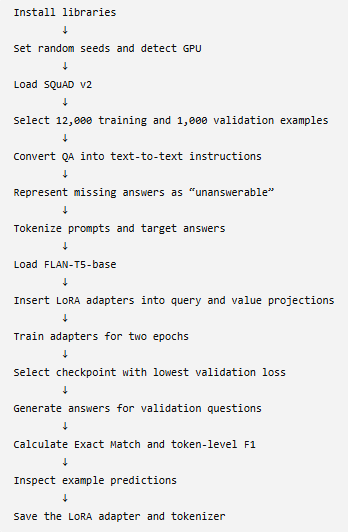

What is genuinely new?
1. Training a generative QA model

The earlier QA notebook used an already fine-tuned RoBERTa model for extractive inference.

This notebook trains FLAN‑T5 with LoRA:

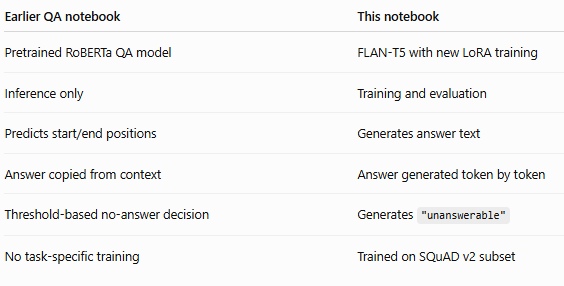

2. Explicit unanswerable target

In [1]:
# Colab setup for text-only Hugging Face workflows.
# torchao/torchvision/timm are optional here and can conflict with Colab's preinstalled PyTorch.
%pip uninstall -y torchao torchvision timm
%pip install -q -U \
    "transformers>=4.57,<6" \
    "datasets>=4,<5" \
    "accelerate>=1.10,<2" \
    "evaluate>=0.4,<1" \
    "sentencepiece>=0.2,<1" \
    "scikit-learn>=1.5,<2"

%pip install -q -U "peft>=0.18,<1" "rouge-score>=0.1,<1"

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: timm 1.0.28
Uninstalling timm-1.0.28:
  Successfully uninstalled timm-1.0.28
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 127.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 48.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.7 requires torchvision>=0.11, which is not installed

In [2]:
import random
import numpy as np
import torch
import transformers
import datasets
import peft
import accelerate

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
Transformers: 5.14.1
PEFT: 0.20.0
CUDA available: True


## Load SQuAD v2 and prepare text-to-text examples

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer

MODEL_NAME = "google/flan-t5-base"

# SQuAD v2 contains two types of examples:

# Answerable: the context contains an answer.
# Unanswerable: the context does not support an answer.

TRAIN_SAMPLES = 12_000
VALIDATION_SAMPLES = 1_000

#These are small experimental subsets rather than the complete dataset.

MAX_INPUT_LENGTH = 384
MAX_TARGET_LENGTH = 64

raw_dataset = load_dataset("rajpurkar/squad_v2")

train_raw = (
    raw_dataset["train"]
    .shuffle(seed=SEED)
    .select(range(min(TRAIN_SAMPLES, len(raw_dataset["train"]))))
)
validation_raw = (
    raw_dataset["validation"]
    .shuffle(seed=SEED)
    .select(range(min(VALIDATION_SAMPLES, len(raw_dataset["validation"]))))
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def first_answer(answer_dict):
    texts = answer_dict.get("text", [])
    return texts[0].strip() if texts else "unanswerable"

# This helper function prepares the training target.

# If SQuAD supplies an answer, it returns the first answer.
# If the answer list is empty, it returns "unanswerable".

# This is different from the earlier manual RoBERTa QA notebook, where a confidence threshold was used to reject unsupported answers.

# Here, unanswerability is directly learned as a text-generation target.

def preprocess_batch(examples):
    prompts = [
        (
            "Answer the question using only the context. "
            "If the answer is not supported, respond with unanswerable. "
            f"question: {question} context: {context}"
        )
        for question, context in zip(examples["question"], examples["context"])
    ]
    targets = [first_answer(answers) for answers in examples["answers"]]

    return tokenizer(
        prompts,
        text_target=targets,
        max_length=MAX_INPUT_LENGTH,
        max_target_length=MAX_TARGET_LENGTH,
        truncation=True,
    )

train_dataset = train_raw.map(
    preprocess_batch,
    batched=True,
    remove_columns=train_raw.column_names,
)
validation_dataset = validation_raw.map(
    preprocess_batch,
    batched=True,
    remove_columns=validation_raw.column_names,
)

# This function:

# Combines the question and context into an instruction.
# Converts each answer into target text.
# Tokenizes the instruction.
# Tokenizes the answer separately as the label.

print(train_dataset)
print(train_raw[0])

README.md:   0%|          | 0.00/8.92k [00:00<?, ?B/s]

squad_v2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 16.4MB            

squad_v2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

squad_v2/validation-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 1.35MB            

squad_v2/validation-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

...

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 12000
})
{'id': '56e0f3907aa994140058e80a', 'title': 'Canon_law', 'context': 'The Roman Catholic Church canon law also includes the main five rites (groups) of churches which are in full union with the Roman Catholic Church and the Supreme Pontiff:', 'question': 'What term characterizes the intersection of the rites with the Roman Catholic Church?', 'answers': {'text': ['full union'], 'answer_start': [104]}}


## Add LoRA adapters

In [4]:
from transformers import AutoModelForSeq2SeqLM
from peft import LoraConfig, TaskType, get_peft_model

base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q", "v"],
    bias="none",
) #LoRA adapters are inserted into the attention query and value projections.

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

trainable params: 884,736 || all params: 248,462,592 || trainable%: 0.3561


## Train

In [5]:
from transformers import (
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt",
)

use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

training_args = Seq2SeqTrainingArguments(
    output_dir="./flan_t5_squad_v2_lora_output",
    num_train_epochs=2,
    learning_rate=5e-4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    generation_num_beams=2,
    fp16=use_fp16,
    bf16=use_bf16,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    seed=SEED,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
)

trainer.train()
trainer.evaluate()

Epoch,Training Loss,Validation Loss
1,0.668969,0.291332
2,0.568971,0.311127


Training Loss,Validation Loss,Epoch
0.568971,0.291332,2


{'eval_loss': 0.29133152961730957}

## Generate answers and calculate simple exact-match/F1 metrics

In [6]:
import re
import string
from collections import Counter

def normalize_answer(text):
    text = text.lower()
    text = "".join(ch for ch in text if ch not in string.punctuation)
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    return " ".join(text.split())

# It makes comparisons more forgiving by:

# Converting text to lowercase.
# Removing punctuation.
# Removing a, an, and the.
# Removing repeated whitespace.

def exact_match(prediction, reference):
    return float(normalize_answer(prediction) == normalize_answer(reference))

# Returns:

# 1.0 when normalized prediction and reference are identical.
# 0.0 otherwise.

def token_f1(prediction, reference):
    pred_tokens = normalize_answer(prediction).split()
    ref_tokens = normalize_answer(reference).split()
    common = Counter(pred_tokens) & Counter(ref_tokens)
    overlap = sum(common.values())
    if not pred_tokens or not ref_tokens:
        return float(pred_tokens == ref_tokens)
    if overlap == 0:
        return 0.0
    precision = overlap / len(pred_tokens)
    recall = overlap / len(ref_tokens)
    return 2 * precision * recall / (precision + recall)

device = next(model.parameters()).device

def answer_question(question, context):
    prompt = (
        "Answer the question using only the context. "
        "If the answer is not supported, respond with unanswerable. "
        f"question: {question} context: {context}"
    )
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LENGTH,
    ).to(device)
    model.eval()
    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=MAX_TARGET_LENGTH,
            num_beams=2,
        )
    return tokenizer.decode(output[0], skip_special_tokens=True).strip()

# This function:

# Builds the same instruction used during training.
# Tokenizes the question and context.
# Moves tensors to the model’s device.
# Generates an answer with beam search.
# Decodes the answer into text.
# Unlike extractive RoBERTa, FLAN‑T5 can generate words that are not copied exactly from the context. This provides flexibility but also creates a risk of hallucination.

sample_count = min(100, len(validation_raw))
em_scores, f1_scores = [], []

for example in validation_raw.select(range(sample_count)):
    prediction = answer_question(example["question"], example["context"])
    reference = first_answer(example["answers"])
    em_scores.append(exact_match(prediction, reference))
    f1_scores.append(token_f1(prediction, reference))

print(f"Exact match on {sample_count} examples: {100*np.mean(em_scores):.2f}")
print(f"Token F1 on {sample_count} examples: {100*np.mean(f1_scores):.2f}")

Exact match on 100 examples: 73.00
Token F1 on 100 examples: 77.68


## Inspect examples

In [7]:
for example in validation_raw.select(range(5)):
    prediction = answer_question(example["question"], example["context"])
    reference = first_answer(example["answers"])
    print("Question:", example["question"])
    print("Reference:", reference)
    print("Prediction:", prediction)
    print("-" * 80)

Question: Where did Marin build first fort?
Reference: Fort Presque Isle (near present-day Erie, Pennsylvania
Prediction: Fort Presque Isle
--------------------------------------------------------------------------------
Question: What increases or decreases in response to static friction?
Reference: unanswerable
Prediction: unanswerable
--------------------------------------------------------------------------------
Question: What would Henry David Thoreau quote to audiences in India?
Reference: unanswerable
Prediction: unanswerable
--------------------------------------------------------------------------------
Question: What revolution was fought in the 1899's?
Reference: unanswerable
Prediction: unanswerable
--------------------------------------------------------------------------------
Question: How are the rates of social goods in countries with lower inequality?
Reference: unanswerable
Prediction: lower
---------------------------------------------------------------------------

## Save the LoRA adapter

In [8]:
ADAPTER_DIR = "./flan_t5_squad_v2_lora_adapter"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print("Saved adapter to:", ADAPTER_DIR)

Saved adapter to: ./flan_t5_squad_v2_lora_adapter
